In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [2]:
data = pd.read_csv("/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")

In [3]:
#taking only 20,000 data
df = data.iloc[:20000]

In [4]:
df.head()
df.shape

(20000, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     20000 non-null  object
 1   sentiment  20000 non-null  object
dtypes: object(2)
memory usage: 312.6+ KB


In [6]:
df["review"][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

# Step 1 : Cleaning The Dataset
* removing duplicate values
* lowercasing
* removing leading and trailing spaces
* removing html tags
* removing urls
* expanding abbreviations
* spelling correction
* punctuations
* remove special characters

***removing duplicate values***

In [7]:
df.duplicated().sum()

np.int64(74)

In [8]:
# removing duplicate values
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19926 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     19926 non-null  object
 1   sentiment  19926 non-null  object
dtypes: object(2)
memory usage: 467.0+ KB


***lowercasing***

In [9]:
# lowercasing
df['review'] = df['review'].str.lower()

In [10]:
df['review'][2]

'i thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. the plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). while some may be disappointed when they realize this is not match point 2: risk addiction, i thought it was proof that woody allen is still fully in control of the style many of us have grown to love.<br /><br />this was the most i\'d laughed at one of woody\'s comedies in years (dare i say a decade?). while i\'ve never been impressed with scarlet johanson, in this she managed to tone down her "sexy" image and jumped right into a average, but spirited young woman.<br /><br />this may not be the crown jewel of his career, but it was wittier than "devil wears prada" and more interesting than "superman" a great comedy to go see with friends.'

***removing leading and trailing spaces***

In [11]:
# removing leading and trailing spaces
df['review'] = df['review'].str.strip()
df['review'][2]

'i thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. the plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). while some may be disappointed when they realize this is not match point 2: risk addiction, i thought it was proof that woody allen is still fully in control of the style many of us have grown to love.<br /><br />this was the most i\'d laughed at one of woody\'s comedies in years (dare i say a decade?). while i\'ve never been impressed with scarlet johanson, in this she managed to tone down her "sexy" image and jumped right into a average, but spirited young woman.<br /><br />this may not be the crown jewel of his career, but it was wittier than "devil wears prada" and more interesting than "superman" a great comedy to go see with friends.'

***removing html tags***

In [12]:
import re
def remove_html(data):
    data = re.sub(r'<.*?>','',data)
    return data

In [13]:
remove_html('<p> my name is abhishek <p><br>')

' my name is abhishek '

In [14]:
# removing html tags
df['review'] = df['review'].apply(remove_html)

In [15]:
df['review'][0]

"one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes where other shows wo

***removing urls***

In [16]:
def remove_url(data):
    data = re.sub(r'https?://\S+|www\.\S+','',data)
    return data

In [17]:
remove_url('to register login https://www.facebook.co.in')

'to register login '

In [18]:
df['review'][df['review'].str.contains('https?://\S+|www\.\S+')].iloc[0]

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_16/1075842349.py:1: SyntaxWarning: invalid escape sequence '\S'
  df['review'][df['review'].str.contains('https?://\S+|www\.\S+')].iloc[0]


'mario lewis of the competitive enterprise institute has written a definitive 120-page point-by-point, line-by-line refutation of this mendacious film, which should be titled a convenient lie. the website address where his debunking report, which is titled "a skeptic\'s guide to an inconvenient truth" can be found at is :www.cei.org. a shorter 10-page version can be found at: www.cei.org/pdf/5539.pdf once you read those demolitions, you\'ll realize that alleged "global warming" is no more real or dangerous than the y2k scare of 1999, which gore also endorsed, as he did the pseudo-scientific film the day after tomorrow, which was based on a book written by alleged ufo abductee whitley strieber. as james "the amazing" randi does to psychics, and philip klass does to ufos, and gerald posner does to jfk conspir-idiocy theories, so does mario lewis does to al gore\'s movie and the whole "global warming" scam.'

In [19]:
#removing urls
df['review']= df['review'].apply(remove_url)

In [20]:
df['review'].iloc[742]

'mario lewis of the competitive enterprise institute has written a definitive 120-page point-by-point, line-by-line refutation of this mendacious film, which should be titled a convenient lie. the website address where his debunking report, which is titled "a skeptic\'s guide to an inconvenient truth" can be found at is : a shorter 10-page version can be found at:  once you read those demolitions, you\'ll realize that alleged "global warming" is no more real or dangerous than the y2k scare of 1999, which gore also endorsed, as he did the pseudo-scientific film the day after tomorrow, which was based on a book written by alleged ufo abductee whitley strieber. as james "the amazing" randi does to psychics, and philip klass does to ufos, and gerald posner does to jfk conspir-idiocy theories, so does mario lewis does to al gore\'s movie and the whole "global warming" scam.'

***expanding abbreviations***

In [21]:
# replacement data many are capitalize
def remove_abb(data):
    data = re.sub(r"he's", "he is", data)
    data = re.sub(r"there's", "there is", data)
    data = re.sub(r"We're", "we are", data)
    data = re.sub(r"That's", "that is", data)
    data = re.sub(r"won't", "will not", data)
    data = re.sub(r"they're", "they are", data)
    data = re.sub(r"Can't", "cannot", data)
    data = re.sub(r"wasn't", "was not", data)
    data = re.sub(r"don\x89Ûªt", "do not", data)
    data= re.sub(r"aren't", "are not", data)
    data = re.sub(r"isn't", "is not", data)
    data = re.sub(r"What's", "what is", data)
    data = re.sub(r"haven't", "have not", data)
    data = re.sub(r"hasn't", "has not", data)
    data = re.sub(r"There's", "There is", data)
    data = re.sub(r"He's", "He is", data)
    data = re.sub(r"It's", "It is", data)
    data = re.sub(r"You're", "You are", data)
    data = re.sub(r"I'M", "I am", data)
    data = re.sub(r"shouldn't", "should not", data)
    data = re.sub(r"wouldn't", "would not", data)
    data = re.sub(r"i'm", "I am", data)
    data = re.sub(r"I\x89Ûªm", "I am", data)
    data = re.sub(r"I'm", "I am", data)
    data = re.sub(r"Isn't", "is not", data)
    data = re.sub(r"Here's", "Here is", data)
    data = re.sub(r"you've", "you have", data)
    data = re.sub(r"you\x89Ûªve", "you have", data)
    data = re.sub(r"we're", "we are", data)
    data = re.sub(r"what's", "what is", data)
    data = re.sub(r"couldn't", "could not", data)
    data = re.sub(r"we've", "we have", data)
    data = re.sub(r"it\x89Ûªs", "it is", data)
    data = re.sub(r"doesn\x89Ûªt", "does not", data)
    data = re.sub(r"It\x89Ûªs", "It is", data)
    data = re.sub(r"Here\x89Ûªs", "Here is", data)
    data = re.sub(r"who's", "who is", data)
    data = re.sub(r"I\x89Ûªve", "I have", data)
    data = re.sub(r"y'all", "you all", data)
    data = re.sub(r"can\x89Ûªt", "cannot", data)
    data = re.sub(r"would've", "would have", data)
    data = re.sub(r"it'll", "it will", data)
    data = re.sub(r"we'll", "we will", data)
    data = re.sub(r"wouldn\x89Ûªt", "would not", data)
    data = re.sub(r"We've", "We have", data)
    data = re.sub(r"he'll", "he will", data)
    data = re.sub(r"Y'all", "You all", data)
    data = re.sub(r"Weren't", "Were not", data)
    data = re.sub(r"Didn't", "Did not", data)
    data = re.sub(r"they'll", "they will", data)
    data = re.sub(r"they'd", "they would", data)
    data = re.sub(r"DON'T", "DO NOT", data)
    data = re.sub(r"That\x89Ûªs", "That is", data)
    data = re.sub(r"they've", "they have", data)
    data = re.sub(r"i'd", "I would", data)
    data = re.sub(r"should've", "should have", data)
    data = re.sub(r"You\x89Ûªre", "You are", data)
    data = re.sub(r"where's", "where is", data)
    data = re.sub(r"Don\x89Ûªt", "Do not", data)
    data = re.sub(r"we'd", "we would", data)
    data = re.sub(r"i'll", "I will", data)
    data = re.sub(r"weren't", "were not", data)
    data = re.sub(r"They're", "They are", data)
    data = re.sub(r"Can\x89Ûªt", "Cannot", data)
    data = re.sub(r"you\x89Ûªll", "you will", data)
    data = re.sub(r"I\x89Ûªd", "I would", data)
    data = re.sub(r"let's", "let us", data)
    data = re.sub(r"it's", "it is", data)
    data = re.sub(r"can't", "cannot", data)
    data = re.sub(r"don't", "do not", data)
    data = re.sub(r"you're", "you are", data)
    data = re.sub(r"i've", "I have", data)
    data = re.sub(r"that's", "that is", data)
    data = re.sub(r"i'll", "I will", data)
    data = re.sub(r"doesn't", "does not",data)
    data = re.sub(r"i'd", "I would", data)
    data = re.sub(r"didn't", "did not", data)
    data = re.sub(r"ain't", "am not", data)
    data = re.sub(r"you'll", "you will", data)
    data = re.sub(r"I've", "I have", data)
    data = re.sub(r"Don't", "do not", data)
    data = re.sub(r"I'll", "I will", data)
    data = re.sub(r"I'd", "I would", data)
    data = re.sub(r"Let's", "Let us", data)
    data = re.sub(r"you'd", "You would", data)
    data = re.sub(r"It's", "It is", data)
    data = re.sub(r"Ain't", "am not", data)
    data = re.sub(r"Haven't", "Have not", data)
    data = re.sub(r"Could've", "Could have", data)
    data = re.sub(r"youve", "you have", data)  
    data = re.sub(r"donå«t", "do not", data)
    data = re.sub(r"who'll","who will",data)
    
    return data

In [22]:
remove_abb("I don't know")

'I do not know'

In [23]:
# expanding abbreviations
df['review'] = df['review'].apply(remove_abb)


In [24]:
df['review'] = df['review'].str.lower()

In [25]:
df['review'][0]

'one of the other reviewers has mentioned that after watching just 1 oz episode you will be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes where other shows 

***spelling correction***

In [26]:
# Installation autocorrect
!pip install autocorrect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 622.8/622.8 kB 15.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for autocorrect: filename=autocorrect-2.6.1-py3-none-any.whl size=622364 sha256=e4f912f7cb5db54ce0880d8457d1e673d4d98083cc916c379d74e33046b7c023
  Stored in directory: /root/.cache/pip/wheels/b6/28/c2/9ddf8f57f871b55b6fd0ab99c887531fb9a66e5ff236b82aee
Successfully built autocorrect


In [27]:
from autocorrect import Speller
spell = Speller()

In [28]:
text = 'I am drve at nigt'
spell(text)

'I am drive at night'

In [29]:
!pip install pandarallel

  Preparing metadata (setup.py) ... done
  Created wheel for pandarallel: filename=pandarallel-1.6.5-py3-none-any.whl size=16674 sha256=5fdf7ea75e3a815694e947eefaf7129be9653fac0846b47717b5585fb03c352a
  Stored in directory: /root/.cache/pip/wheels/46/f9/0d/40c9cd74a7cb8dc8fe57e8d6c3c19e2c730449c0d3f2bf66b5
Successfully built pandarallel


In [30]:
from pandarallel import pandarallel
pandarallel.initialize(progress_bar=True)

INFO: Pandarallel will run on 2 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [31]:
# spelling correction 
# df['review']= df['review'].parallel_apply(spell) 

In [32]:
df['review'][0]

'one of the other reviewers has mentioned that after watching just 1 oz episode you will be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes where other shows 

***remove punctuations***

In [33]:
import string

In [34]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [35]:
def remove_punctuation(text):
    for i in string.punctuation:
        if i in text:
            text = text.replace(i,"")
    return text

In [36]:
remove_punctuation("Hi there! how are you?")

'Hi there how are you'

In [37]:
# remove punctuations
df['review'] = df['review'].apply(remove_punctuation)

In [38]:
df['review'][0]

'one of the other reviewers has mentioned that after watching just 1 oz episode you will be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordit is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awayi would say the main appeal of the show is due to the fact that it goes where other shows would not dare forget pretty p

***removing special chars***

In [39]:
def remove_spacial_char(data):
    data = re.sub(r'[^\w\s]', '', data)
    return data

In [40]:
remove_spacial_char("contact me - \\in abhishek@098mail.com!!")

'contact me  in abhishek098mailcom'

In [41]:
# removing special chars
df['review'] = df['review'].apply(remove_spacial_char)

# Preprocessing
* tokenization(keep string)
* removing stopwords

***tokenization***

In [42]:
from nltk.tokenize import word_tokenize

In [43]:
df['tokenized_review'] = df['review'].apply(word_tokenize)

In [44]:
df.head()

,review,sentiment,tokenized_review
0,one of the other reviewers has mentioned that ...,positive,"[one, of, the, other, reviewers, has, mentione..."
1,a wonderful little production the filming tech...,positive,"[a, wonderful, little, production, the, filmin..."
2,i thought this was a wonderful way to spend ti...,positive,"[i, thought, this, was, a, wonderful, way, to,..."
3,basically there is a family where a little boy...,negative,"[basically, there, is, a, family, where, a, li..."
4,petter matteis love in the time of money is a ...,positive,"[petter, matteis, love, in, the, time, of, mon..."


***stopword removal***

In [45]:
from nltk.corpus import stopwords

In [46]:
# stopwords.words('english')
def remove_stopwords(text):
    l=[]
    for word in text:
        if word not in stopwords.words('english'):
            l.append(word)
    return l

In [47]:
remove_stopwords(['i', 'am', 'abhishek'])

['abhishek']

In [48]:
df['tokenized_review'] = df['tokenized_review'].parallel_apply(remove_stopwords)

In [49]:
df['tokenized_review'][0]

['one',
 'reviewers',
 'mentioned',
 'watching',
 '1',
 'oz',
 'episode',
 'hooked',
 'right',
 'exactly',
 'happened',
 'methe',
 'first',
 'thing',
 'struck',
 'oz',
 'brutality',
 'unflinching',
 'scenes',
 'violence',
 'set',
 'right',
 'word',
 'go',
 'trust',
 'show',
 'faint',
 'hearted',
 'timid',
 'show',
 'pulls',
 'punches',
 'regards',
 'drugs',
 'sex',
 'violence',
 'hardcore',
 'classic',
 'use',
 'wordit',
 'called',
 'oz',
 'nickname',
 'given',
 'oswald',
 'maximum',
 'security',
 'state',
 'penitentary',
 'focuses',
 'mainly',
 'emerald',
 'city',
 'experimental',
 'section',
 'prison',
 'cells',
 'glass',
 'fronts',
 'face',
 'inwards',
 'privacy',
 'high',
 'agenda',
 'em',
 'city',
 'home',
 'manyaryans',
 'muslims',
 'gangstas',
 'latinos',
 'christians',
 'italians',
 'irish',
 'moreso',
 'scuffles',
 'death',
 'stares',
 'dodgy',
 'dealings',
 'shady',
 'agreements',
 'never',
 'far',
 'awayi',
 'would',
 'say',
 'main',
 'appeal',
 'show',
 'due',
 'fact',
 'go

# EDA and Feature Engineering
* Distribution of text length/word count
* Common unigrams/bigrams/trigrams
* wordcloud

In [50]:
# Distribution word count
def word_count(text):
    l = 0
    for i in text:
        l+=1
    return l

In [51]:
word_count(['Hi','My','name','Abhishek'])

4

In [52]:
df['word_count'] = df['tokenized_review'].parallel_apply(word_count)

In [53]:
df

,review,sentiment,tokenized_review,word_count
0,one of the other reviewers has mentioned that ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e...",164
1,a wonderful little production the filming tech...,positive,"[wonderful, little, production, filming, techn...",84
2,i thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su...",85
3,basically there is a family where a little boy...,negative,"[basically, family, little, boy, jake, thinks,...",64
4,petter matteis love in the time of money is a ...,positive,"[petter, matteis, love, time, money, visually,...",125
...,...,...,...,...
19995,ok for starters taxi driver is amazing this th...,negative,"[ok, starters, taxi, driver, amazing, taxi, dr...",60
19996,it is sort of hard for me to say it because i ...,negative,"[sort, hard, say, greatly, enjoyed, targets, p...",254
19997,i still liked it though warren beatty is only ...,positive,"[still, liked, though, warren, beatty, fair, c...",174
19998,we could still use black adder even today imag...,positive,"[could, still, use, black, adder, even, today,...",109


In [54]:
#update review
df['review']=df['tokenized_review'].apply(lambda x : " ".join(x))

In [55]:
df

,review,sentiment,tokenized_review,word_count
0,one reviewers mentioned watching 1 oz episode ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e...",164
1,wonderful little production filming technique ...,positive,"[wonderful, little, production, filming, techn...",84
2,thought wonderful way spend time hot summer we...,positive,"[thought, wonderful, way, spend, time, hot, su...",85
3,basically family little boy jake thinks zombie...,negative,"[basically, family, little, boy, jake, thinks,...",64
4,petter matteis love time money visually stunni...,positive,"[petter, matteis, love, time, money, visually,...",125
...,...,...,...,...
19995,ok starters taxi driver amazing taxi driver am...,negative,"[ok, starters, taxi, driver, amazing, taxi, dr...",60
19996,sort hard say greatly enjoyed targets paper mo...,negative,"[sort, hard, say, greatly, enjoyed, targets, p...",254
19997,still liked though warren beatty fair comic bo...,positive,"[still, liked, though, warren, beatty, fair, c...",174
19998,could still use black adder even today imagine...,positive,"[could, still, use, black, adder, even, today,...",109


In [56]:
#Distribution of text length
df['char_len'] = df['review'].str.len()

In [57]:
df

,review,sentiment,tokenized_review,word_count,char_len
0,one reviewers mentioned watching 1 oz episode ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e...",164,1130
1,wonderful little production filming technique ...,positive,"[wonderful, little, production, filming, techn...",84,656
2,thought wonderful way spend time hot summer we...,positive,"[thought, wonderful, way, spend, time, hot, su...",85,588
3,basically family little boy jake thinks zombie...,negative,"[basically, family, little, boy, jake, thinks,...",64,440
4,petter matteis love time money visually stunni...,positive,"[petter, matteis, love, time, money, visually,...",125,863
...,...,...,...,...,...
19995,ok starters taxi driver amazing taxi driver am...,negative,"[ok, starters, taxi, driver, amazing, taxi, dr...",60,378
19996,sort hard say greatly enjoyed targets paper mo...,negative,"[sort, hard, say, greatly, enjoyed, targets, p...",254,1822
19997,still liked though warren beatty fair comic bo...,positive,"[still, liked, though, warren, beatty, fair, c...",174,1141
19998,could still use black adder even today imagine...,positive,"[could, still, use, black, adder, even, today,...",109,724


In [58]:
import seaborn as sns

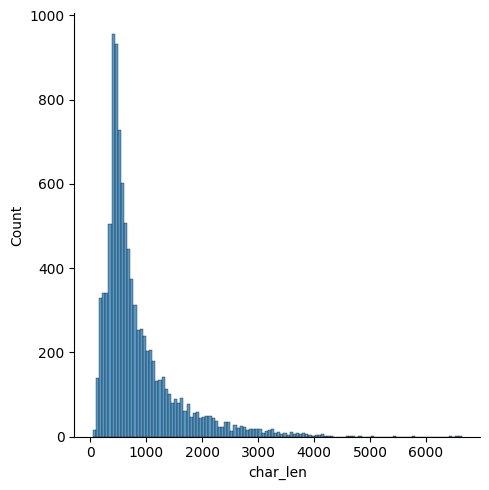

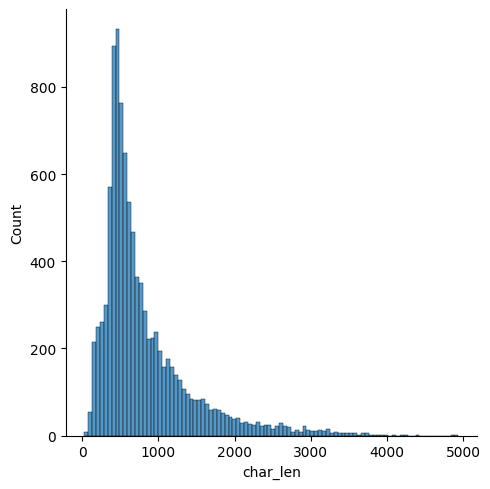

In [59]:
sns.displot(df[df['sentiment'] == 'positive']['char_len'])
sns.displot(df[df['sentiment'] == 'negative']['char_len'])

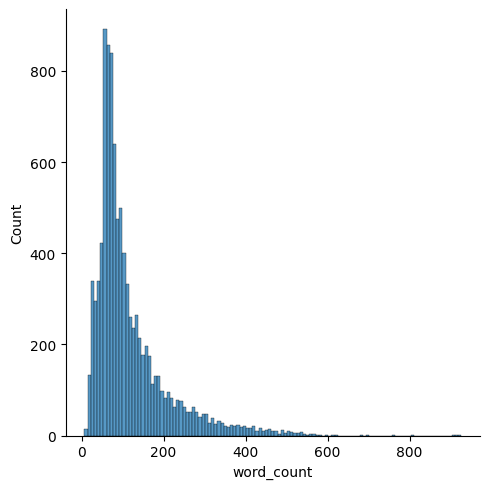

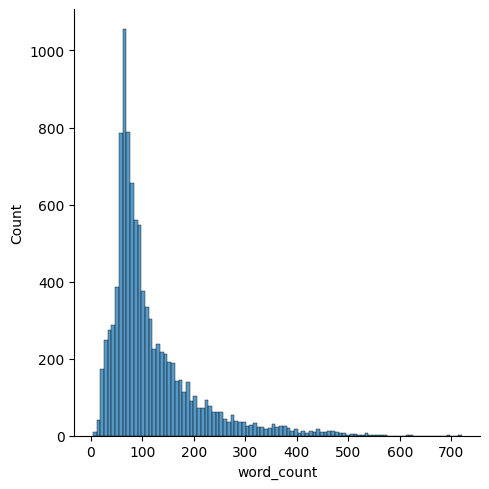

In [60]:
sns.displot(df[df['sentiment'] == 'positive']['word_count'])
sns.displot(df[df['sentiment'] == 'negative']['word_count'])

In [61]:
# df['tokenized_review'].sum()

In [62]:
from nltk import ngrams
pd.Series(ngrams(df['tokenized_review'].sum(),2)).value_counts()

(ever, seen)             977
(special, effects)       856
(even, though)           746
(one, best)              740
(looks, like)            619
                        ... 
(oz, episode)              1
(1, oz)                    1
(mentioned, watching)      1
(lies, seem)               1
(happen, earth)            1
Name: count, Length: 1536300, dtype: int64

In [63]:
pd.Series(ngrams(df['tokenized_review'].sum(),3)).value_counts()

(movie, ever, seen)          198
(worst, movie, ever)         187
(movies, ever, seen)         124
(one, worst, movies)         116
(worst, movies, ever)        106
                            ... 
(really, big, erotic)          1
(big, erotic, aspects)         1
(erotic, aspects, genre)       1
(aspects, genre, monster)      1
(door, parents, bedroom)       1
Name: count, Length: 2258043, dtype: int64

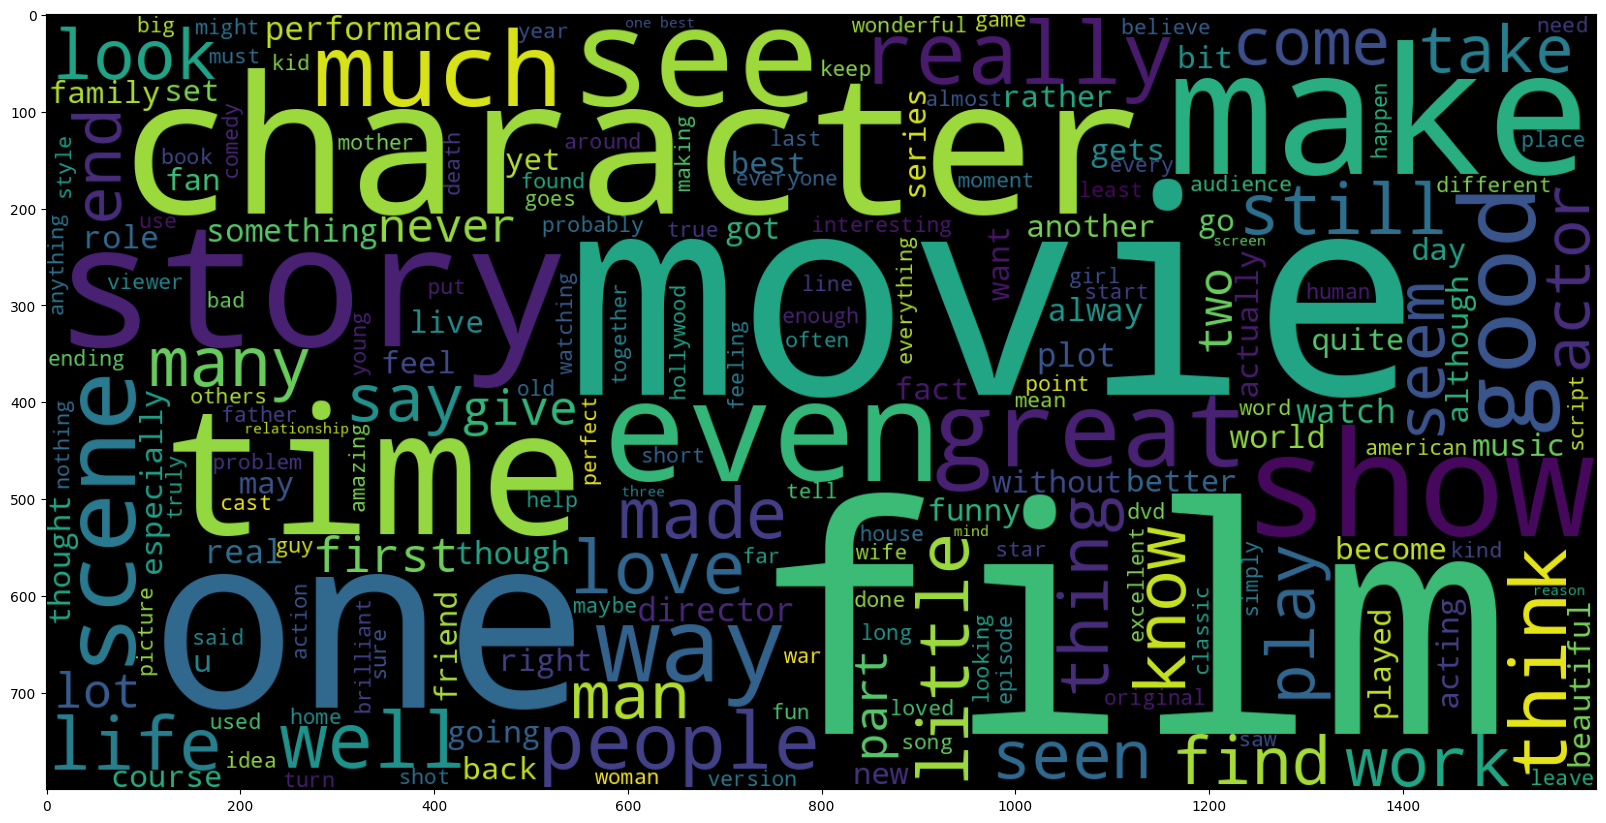

In [64]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

plt.figure(figsize = (20,20))
wc = WordCloud(width = 1600, height= 800).generate(''.join(df[df['sentiment']=='positive']['review']))
plt.imshow(wc)

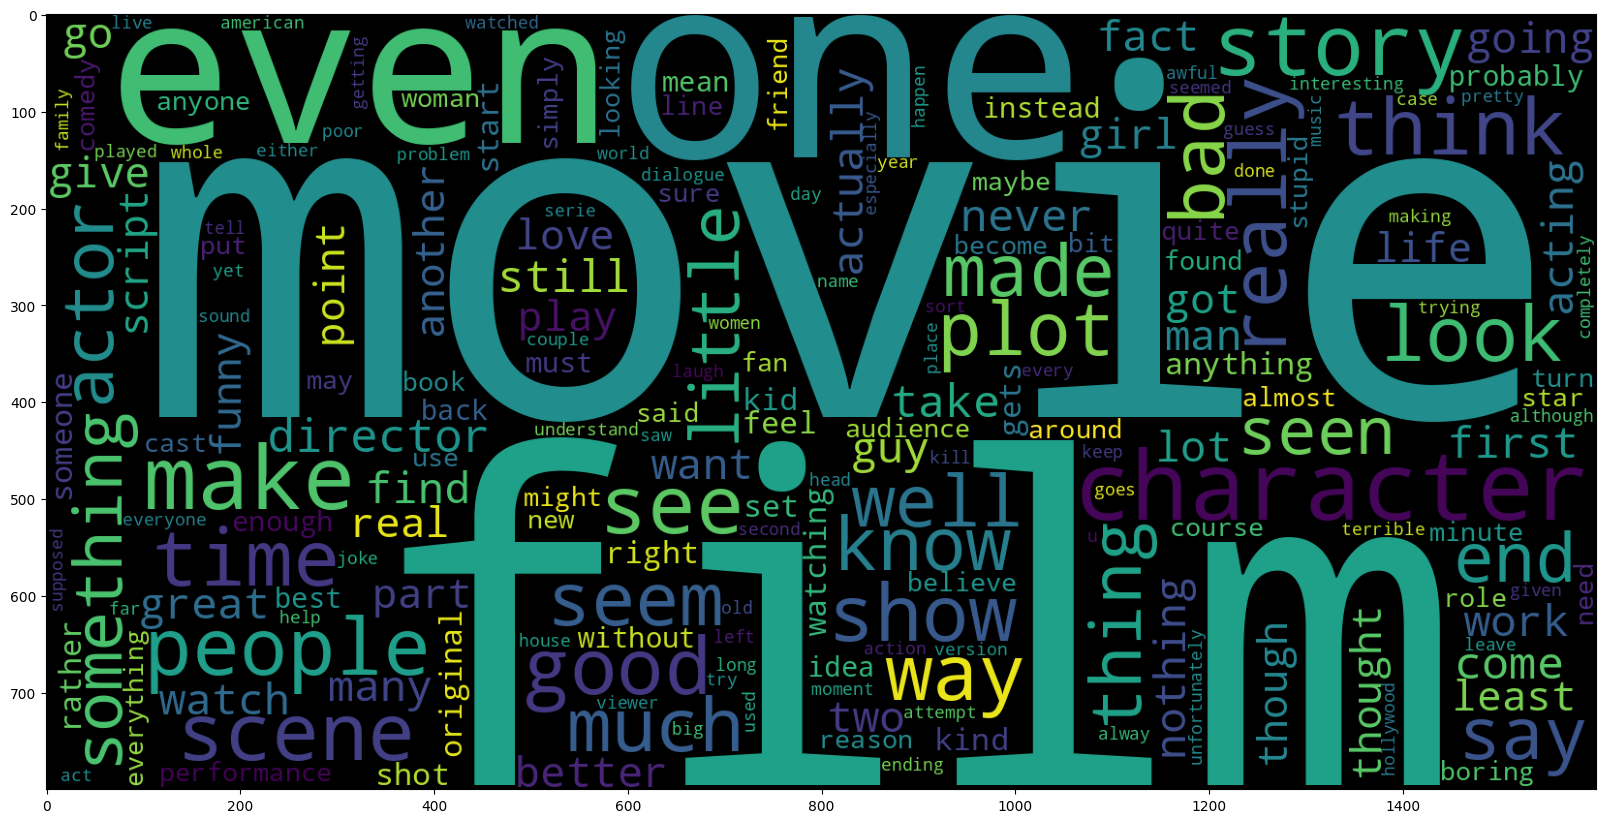

In [65]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

plt.figure(figsize = (20,20))
wc = WordCloud(width = 1600, height= 800).generate(''.join(df[df['sentiment']=='negative']['review']))
plt.imshow(wc)

# Vectorization
* ***BOW*** -> **Bag of words**

In [66]:
from sklearn.feature_extraction.text import CountVectorizer
count_vectorizer = CountVectorizer(max_features=10000,ngram_range=(2,2))
bag_of_words = count_vectorizer.fit_transform(df['review'])
bag_of_words = pd.DataFrame(bag_of_words.toarray(),columns = count_vectorizer.get_feature_names_out())

In [67]:
bag_of_words

,10 10,10 lines,10 minutes,10 seconds,10 stars,10 times,10 year,10 years,100 minutes,100 times,...,younger sister,younger woman,yul brynner,zero stars,zoey 101,zombie bloodbath,zombie film,zombie films,zombie movie,zombie movies
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19921,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19922,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19923,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19924,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Additionals
* **PCA** --> make high dimension data to low dimension data
* **Stemming**
* **POS tagging**

In [68]:
#PCA
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
pca_result = pca.fit_transform(bag_of_words.values)

In [69]:
pca_result

array([[-0.12616212, -0.04358339],
       [-0.16597359, -0.05262188],
       [-0.13376352, -0.07708191],
       ...,
       [ 0.64072214,  0.52413477],
       [-0.12291869, -0.01200243],
       [-0.10377599, -0.05654701]], shape=(19926, 2))

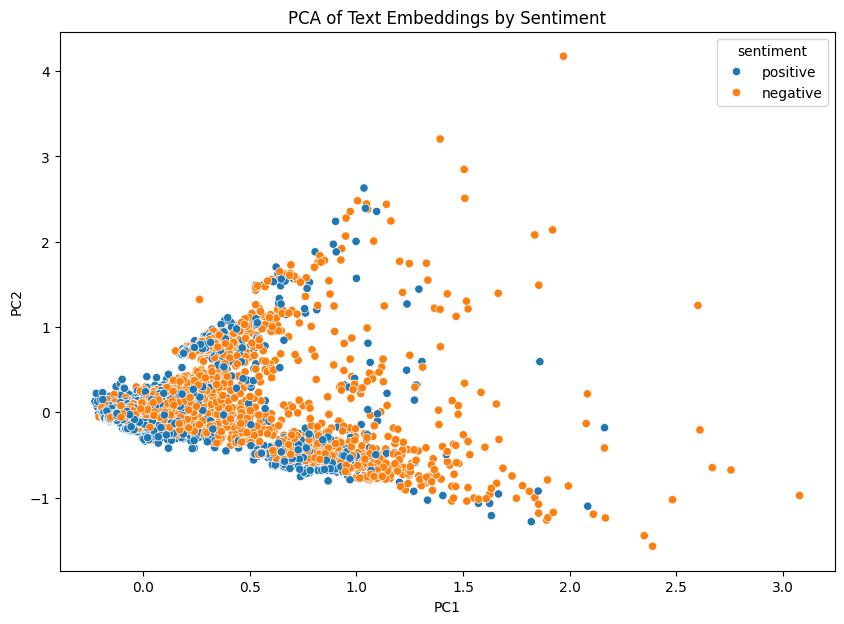

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Explicitly assign x and y keyword arguments
sns.scatterplot(
    x=pca_result[:, 0], 
    y=pca_result[:, 1], 
    hue=df['sentiment']
)

plt.title('PCA of Text Embeddings by Sentiment')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()